# 05 - Temporal Convolutional Network (TCN)
Owner: Engineer 3 (or reassigned)

Causal, dilated, residual convolutions - each block doubles the dilation so the receptive field grows fast. Ablation varies the number of blocks directly.

Result: macro-F1 0.8838, accuracy 0.9951. Similar to LSTM, behind CNN and the baseline.

## 1. Setup
Same as earlier notebooks.

In [1]:
import os, sys, subprocess
from pathlib import Path

REPO_URL = "https://github.com/Manzi453/Formative_2-Group_19.git"
BRANCH = "feature/baseline-tfidf"  # change to main once merged

if "google.colab" in sys.modules:
    if not Path("Formative_2-Group_19").exists():
        subprocess.run(["git", "clone", "-b", BRANCH, REPO_URL], check=True)
    os.chdir("Formative_2-Group_19")
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)
else:
    if Path.cwd().name == "notebooks":
        os.chdir("..")

sys.path.insert(0, str(Path.cwd()))
print("Working directory:", Path.cwd())

Working directory: /Users/manziivan453icloud.com/Downloads/Projects/Ivan /Formative_2-Group_19


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from src.utils import set_seed, SEED, RESULTS_DIR, MODELS_DIR
from src.data_loader import load_raw, make_split, ID_COL, TEXT_COL, LABEL_COL
from src.preprocessing import STRATEGIES
from src.nn_data import build_vocab, encode_batch, encode_labels, DEFAULT_MAX_LEN
from src.nn_models import TCNClassifier
from src.nn_train import train_classifier, predict_logits
from src.eda import length_features
from src.evaluation import compute_metrics, per_class_report, confusion
from src.plotting import save_fig, plot_confusion_matrix, plot_learning_curves
from src.experiments import log_experiment, EXPERIMENTS_CSV

set_seed()
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 50, "display.width", 140)

METRICS = RESULTS_DIR / "metrics"
ERRORS = RESULTS_DIR / "errors"
PREDICTIONS = RESULTS_DIR / "predictions"
TCN_DIR = MODELS_DIR / "tcn"
for d in (METRICS, ERRORS, PREDICTIONS, TCN_DIR):
    d.mkdir(parents=True, exist_ok=True)

DEVICE = "mps" if torch.backends.mps.is_available() else "cpu"
print("seed =", SEED, "| torch", torch.__version__, "| device =", DEVICE)

seed = 42 | torch 2.14.1 | device = mps


## 2. Data, split & preprocessing
Uses notebook 02's preprocessing choice.

In [3]:
train, test, sample = load_raw()
train_df, val_df = make_split(train)
CLASS_ORDER = list(train_df[LABEL_COL].value_counts().index)

prep_log = pd.read_csv(METRICS / "preprocessing_experiments.csv")
prep_log = prep_log.drop_duplicates(subset="experiment_id", keep="last")  # re-running a notebook appends, not overwrites
best_row = prep_log.sort_values("validation_macro_f1", ascending=False).iloc[0]
PREP_STRATEGY = best_row["strategy"]
clean = STRATEGIES[PREP_STRATEGY]
print(f"Using preprocessing strategy '{PREP_STRATEGY}' "
      f"(validation macro-F1={best_row['validation_macro_f1']} for the TF-IDF baseline in notebook 02).")

train_text = train_df[TEXT_COL].map(clean)
val_text = val_df[TEXT_COL].map(clean)
y_train = encode_labels(train_df[LABEL_COL], CLASS_ORDER)
y_val = encode_labels(val_df[LABEL_COL], CLASS_ORDER)
print(f"train={len(train_df):,}  validation={len(val_df):,}  classes={CLASS_ORDER}")

Using preprocessing strategy 'A_minimal' (validation macro-F1=0.9747 for the TF-IDF baseline in notebook 02).
train=31,719  validation=7,931  classes=['sexual_violence', 'Physical_violence', 'emotional_violence', 'economic_violence', 'Harmful_Traditional_practice']


## 3. Vocabulary and encoding
Same rule as 03/04. Sequence length fixed at 64.

In [4]:
VOCAB = build_vocab(train_text, min_freq=2)
MAX_LEN = DEFAULT_MAX_LEN
X_train_full = encode_batch(train_text, VOCAB, MAX_LEN)
X_val_full = encode_batch(val_text, VOCAB, MAX_LEN)
print(f"vocabulary size (min_freq=2): {len(VOCAB):,} | max_len={MAX_LEN}")

vocabulary size (min_freq=2): 16,867 | max_len=64


## 4. Controlled experiments: receptive field via block count
More blocks = bigger receptive field (see `TCNClassifier.receptive_field`). Three configs, short budget, just to rank them.

In [5]:
ABLATION_CONFIGS = {
    "tcn_levels3": dict(levels=3, kernel_size=3),
    "tcn_levels4": dict(levels=4, kernel_size=3),
    "tcn_levels5": dict(levels=5, kernel_size=3),
}
EMBED_DIM, CHANNELS = 100, 100

ablation_rows = []
for exp_id, cfg in ABLATION_CONFIGS.items():
    torch.manual_seed(SEED)
    model = TCNClassifier(vocab_size=len(VOCAB), n_classes=len(CLASS_ORDER),
                           embed_dim=EMBED_DIM, channels=CHANNELS, **cfg)
    _, _, best_f1, train_time = train_classifier(
        model, X_train_full, y_train, X_val_full, y_val,
        epochs=4, batch_size=2048, lr=1e-3, device=DEVICE, patience=2, seed=SEED, verbose=False,
    )
    ablation_rows.append({"experiment_id": exp_id, "levels": cfg["levels"],
                           "receptive_field": model.receptive_field,
                           "val_macro_f1": round(best_f1, 4), "train_time_s": round(train_time, 1)})
    print(f"{exp_id}: receptive_field={model.receptive_field} tokens | "
          f"val_macro_f1={best_f1:.4f} ({train_time:.1f}s)")

ablation_results = pd.DataFrame(ablation_rows).sort_values("val_macro_f1", ascending=False).reset_index(drop=True)
ablation_results

tcn_levels3: receptive_field=29 tokens | val_macro_f1=0.3886 (79.9s)
tcn_levels4: receptive_field=61 tokens | val_macro_f1=0.3860 (43.3s)
tcn_levels5: receptive_field=125 tokens | val_macro_f1=0.3899 (60.1s)


,experiment_id,levels,receptive_field,val_macro_f1,train_time_s
0,tcn_levels5,5,125,0.3899,60.1
1,tcn_levels3,3,29,0.3886,79.9
2,tcn_levels4,4,61,0.3860,43.3


In [6]:
for _, row in ablation_results.iterrows():
    log_experiment(
        experiment_id=row["experiment_id"], model="tcn", preprocessing=PREP_STRATEGY,
        tokenizer="word_level_min_freq_2", sequence_length=MAX_LEN, embedding=f"learned_{EMBED_DIM}d",
        learning_rate=1e-3, batch_size=2048, epochs="<=4 (early stop)", optimizer="adam", dropout=0.3,
        train_time=f"{row['train_time_s']:.1f}s", macro_f1=row["val_macro_f1"],
        notes=f"Controlled ablation over levels={row['levels']} (receptive_field={row['receptive_field']} tokens).",
        next_action="Winning config retrained with a larger epoch budget in section 5.",
    )

BEST_CONFIG_ID = ablation_results.iloc[0]["experiment_id"]
BEST_CONFIG = ABLATION_CONFIGS[BEST_CONFIG_ID]
print(f"Best config: {BEST_CONFIG_ID} -> {BEST_CONFIG}")

Best config: tcn_levels5 -> {'levels': 5, 'kernel_size': 3}


## 5. Final model
Retrains the winner for longer.

In [7]:
torch.manual_seed(SEED)
final_model = TCNClassifier(vocab_size=len(VOCAB), n_classes=len(CLASS_ORDER),
                             embed_dim=EMBED_DIM, channels=CHANNELS, **BEST_CONFIG)
final_model, history, best_f1, train_time = train_classifier(
    final_model, X_train_full, y_train, X_val_full, y_val,
    epochs=20, batch_size=2048, lr=1e-3, device=DEVICE, patience=5, seed=SEED, verbose=True,
)

val_logits = predict_logits(final_model, X_val_full, DEVICE)
val_pred_ids = val_logits.argmax(dim=1).numpy()
val_pred_labels = np.array(CLASS_ORDER)[val_pred_ids]
y_val_labels = np.array(CLASS_ORDER)[y_val]

metrics = compute_metrics(y_val_labels, val_pred_labels)
print(f"config={BEST_CONFIG_ID} | receptive_field={final_model.receptive_field} tokens | "
      f"train_time={train_time:.1f}s | epochs_run={len(history['train_loss'])}")
pd.Series(metrics)

epoch  1/20 | train_loss 0.7234 | val_loss 0.4755 | val_macro_f1 0.2448
epoch  2/20 | train_loss 0.4205 | val_loss 0.3338 | val_macro_f1 0.3352
epoch  3/20 | train_loss 0.2613 | val_loss 0.1664 | val_macro_f1 0.3755
epoch  4/20 | train_loss 0.1421 | val_loss 0.1071 | val_macro_f1 0.3899
epoch  5/20 | train_loss 0.0991 | val_loss 0.0831 | val_macro_f1 0.3936
epoch  6/20 | train_loss 0.0795 | val_loss 0.0709 | val_macro_f1 0.3947
epoch  7/20 | train_loss 0.0684 | val_loss 0.0626 | val_macro_f1 0.4335
epoch  8/20 | train_loss 0.0588 | val_loss 0.0552 | val_macro_f1 0.4888
epoch  9/20 | train_loss 0.0515 | val_loss 0.0486 | val_macro_f1 0.5250
epoch 10/20 | train_loss 0.0442 | val_loss 0.0418 | val_macro_f1 0.5410
epoch 11/20 | train_loss 0.0395 | val_loss 0.0380 | val_macro_f1 0.5437
epoch 12/20 | train_loss 0.0351 | val_loss 0.0339 | val_macro_f1 0.5442
epoch 13/20 | train_loss 0.0293 | val_loss 0.0321 | val_macro_f1 0.5539
epoch 14/20 | train_loss 0.0270 | val_loss 0.0295 | val_macro_f1

validation_accuracy    0.994956
macro_precision        0.893043
macro_recall           0.873854
macro_f1               0.882992
weighted_f1            0.994872
dtype: float64

## 6. Per-class performance, confusion matrix & learning curves

,precision,recall,f1-score,support
Harmful_Traditional_practice,0.735294,0.657895,0.694444,38.000000
Physical_violence,0.995812,0.999160,0.997483,1190.000000
economic_violence,0.767442,0.767442,0.767442,43.000000
emotional_violence,0.968504,0.946154,0.957198,130.000000
sexual_violence,0.998163,0.998622,0.998392,6530.000000
accuracy,0.994956,0.994956,0.994956,0.994956
macro avg,0.893043,0.873854,0.882992,7931.000000
weighted avg,0.994814,0.994956,0.994872,7931.000000


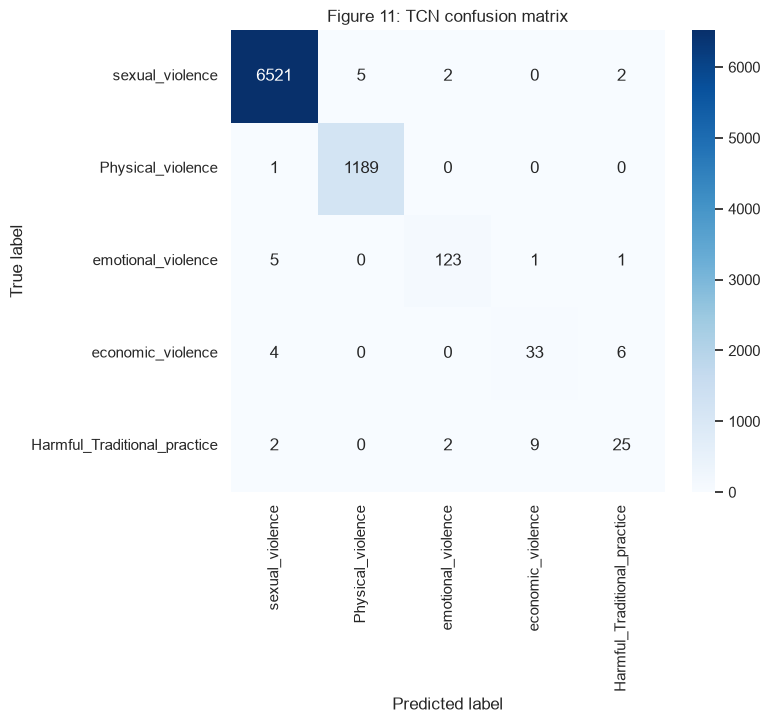

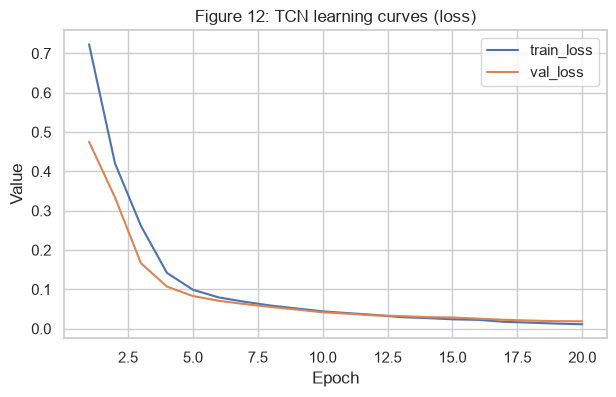

In [8]:
report = per_class_report(y_val_labels, val_pred_labels)
report.to_csv(METRICS / "tcn_per_class_report.csv")
display(report)

cm = confusion(y_val_labels, val_pred_labels, labels=CLASS_ORDER)
fig = plot_confusion_matrix(cm, CLASS_ORDER, "Figure 11: TCN confusion matrix")
save_fig(fig, "fig11_tcn_confusion_matrix")
plt.show()

fig2 = plot_learning_curves(
    {"train_loss": history["train_loss"], "val_loss": history["val_loss"]},
    "Figure 12: TCN learning curves (loss)",
)
save_fig(fig2, "fig12_tcn_learning_curves")
plt.show()

## 7. Error analysis
Misclassified IDs + labels only.

In [9]:
val_lengths = length_features(val_df, TEXT_COL)
mask = val_pred_labels != y_val_labels
errors = val_df.loc[mask, [ID_COL, LABEL_COL]].rename(columns={LABEL_COL: "true_label"}).copy()
errors["predicted"] = val_pred_labels[mask]
errors["tokens"] = val_lengths.loc[errors.index, "tokens"]
errors.to_csv(ERRORS / "tcn_errors.csv", index=False)

print(f"Misclassified: {len(errors)} / {len(val_df)} ({100 * len(errors) / len(val_df):.2f}%)")
errors.groupby(["true_label", "predicted"]).size().sort_values(ascending=False).head(10)

Misclassified: 40 / 7931 (0.50%)


true_label                    predicted                   
Harmful_Traditional_practice  economic_violence               9
economic_violence             Harmful_Traditional_practice    6
emotional_violence            sexual_violence                 5
sexual_violence               Physical_violence               5
economic_violence             sexual_violence                 4
Harmful_Traditional_practice  emotional_violence              2
                              sexual_violence                 2
sexual_violence               Harmful_Traditional_practice    2
                              emotional_violence              2
Physical_violence             sexual_violence                 1
dtype: int64

## 8. Save artifact and log run

In [10]:
CHECKPOINT_PATH = TCN_DIR / "tcn.pt"
torch.save({
    "state_dict": final_model.state_dict(),
    "vocab": VOCAB,
    "classes": CLASS_ORDER,
    "config": {**BEST_CONFIG, "embed_dim": EMBED_DIM, "channels": CHANNELS, "max_len": MAX_LEN},
    "preprocessing": PREP_STRATEGY,
}, CHECKPOINT_PATH)

log_experiment(
    experiment_id="tcn_final_v1", model="tcn", preprocessing=PREP_STRATEGY,
    tokenizer="word_level_min_freq_2", sequence_length=MAX_LEN, embedding=f"learned_{EMBED_DIM}d",
    learning_rate=1e-3, batch_size=2048, epochs=len(history["train_loss"]), optimizer="adam", dropout=0.3,
    train_time=f"{train_time:.1f}s",
    validation_accuracy=round(metrics["validation_accuracy"], 4),
    macro_precision=round(metrics["macro_precision"], 4),
    macro_recall=round(metrics["macro_recall"], 4),
    macro_f1=round(metrics["macro_f1"], 4),
    weighted_f1=round(metrics["weighted_f1"], 4),
    notes=(f"TCN, config={BEST_CONFIG_ID} chosen from the section-4 ablation "
           f"(receptive_field={final_model.receptive_field} tokens)."),
    next_action="Compare against TF-IDF baseline / LSTM / CNN / Transformer in notebook 07.",
)

val_predictions = val_df[[ID_COL]].assign(true_label=y_val_labels, predicted_label=val_pred_labels)
val_predictions.to_csv(PREDICTIONS / "tcn_val_predictions.csv", index=False)
print(f"Saved checkpoint to {CHECKPOINT_PATH}")
print(f"Saved predictions to {PREDICTIONS / 'tcn_val_predictions.csv'}")

Saved checkpoint to /Users/manziivan453icloud.com/Downloads/Projects/Ivan /Formative_2-Group_19/models/tcn/tcn.pt
Saved predictions to /Users/manziivan453icloud.com/Downloads/Projects/Ivan /Formative_2-Group_19/results/predictions/tcn_val_predictions.csv


## 9. Findings
Pulled straight from the tables above.

In [11]:
exp_log = pd.read_csv(EXPERIMENTS_CSV)
exp_log = exp_log.drop_duplicates(subset="experiment_id", keep="last")  # re-running a notebook appends, not overwrites
baseline_f1 = exp_log.loc[exp_log["experiment_id"] == "baseline_tfidf_logreg_v1", "macro_f1"].iloc[0]

findings = {
    "preprocessing strategy (from notebook 02)": PREP_STRATEGY,
    "ablation configs compared": ", ".join(ABLATION_CONFIGS),
    "best config": f"{BEST_CONFIG_ID} ({BEST_CONFIG})",
    "receptive field (tokens)": final_model.receptive_field,
    "final macro-F1": f"{metrics['macro_f1']:.4f}",
    "final accuracy": f"{metrics['validation_accuracy']:.4f}",
    "epochs run (early stopping, patience=3)": len(history["train_loss"]),
    "train time": f"{train_time:.1f}s",
    "misclassified (val)": f"{len(errors)} / {len(val_df)} ({100 * len(errors) / len(val_df):.2f}%)",
    "TF-IDF baseline macro-F1 (notebook 02)": f"{float(baseline_f1):.4f}",
    "TCN vs TF-IDF baseline": f"{metrics['macro_f1'] - float(baseline_f1):+.4f} macro-F1",
}
for other_id, other_name in [("lstm_final_v1", "LSTM"), ("cnn_final_v1", "CNN")]:
    row = exp_log.loc[exp_log["experiment_id"] == other_id, "macro_f1"]
    if len(row):
        findings[f"TCN vs {other_name}"] = f"{metrics['macro_f1'] - float(row.iloc[0]):+.4f} macro-F1"
pd.Series(findings, name="finding").to_frame()

,finding
preprocessing strategy (from notebook 02),A_minimal
ablation configs compared,"tcn_levels3, tcn_levels4, tcn_levels5"
best config,"tcn_levels5 ({'levels': 5, 'kernel_size': 3})"
receptive field (tokens),125
final macro-F1,0.8830
final accuracy,0.9950
"epochs run (early stopping, patience=3)",20
train time,316.8s
misclassified (val),40 / 7931 (0.50%)
TF-IDF baseline macro-F1 (notebook 02),0.9747
